In [1]:
## Import
from data import Data
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

from statsmodels.tsa.stattools import adfuller


d:\venv\time-series-venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
## Get the train data.
# Check if it already exists
if not os.path.exists(r"../data/single-daywise-sales-list-train.csv"):
    print("Premade data not found, cooking it...")
    data = Data()

    prod_id_list = data.get_prod_id_list()
    NUM_DATA = 100

    d1 = pd.DataFrame({"Id": prod_id_list.iloc[0:NUM_DATA],
                        "Day_Wise_Sales": [np.array(data.get_train_data(prod, choice1='train', choice2='single_prod_day_wise'))[0] for prod in tqdm(prod_id_list.iloc[0:NUM_DATA])]                   
                        })
    # Since loading data is slow, store it in csv
    print("Saving data for quicker future use")
    d1.to_csv("../data/single-daywise-sales-list-train.csv")
    print("Data saved successfully")
else:
    print("Premade data found!, loading it...")
    d1 = pd.read_csv("../data/single-daywise-sales-list-train.csv")
    print("Data loaded successfully")


Premade data not found, cooking it...
Data found in 'data' folder
Loading data...
Data loaded succesfully!


100%|██████████| 30490/30490 [1:34:55<00:00,  5.35it/s]    


Saving data for quicker future use
Data saved successfully


In [3]:
## Analyze AutoCorrelation

def get_acf_lag():
    pass

In [4]:
## Analyze Partial AutoCorrelation

def get_pacf_lag():
    pass

In [5]:
(d1['Day_Wise_Sales'].iloc[0])

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 2, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 2, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 2, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 2, 3, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 2, 1, 0, 0, 1, 1, 2, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 3, 0,
       0, 3, 0, 1, 1, 2, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 2, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 2, 0,
       0, 0, 2, 1, 2, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 2, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,

In [6]:
## Analyze affects of differencing
THRESHOLD = 0.05

# Search Space of diff
diff_space = [0, 2, 4]
num_non_staionary_points_list = []
def get_diff_series_df(time_series_df: pd.Series, order: int):
    diff_time_series_df = time_series_df.copy()
    for _ in range(order):
        diff_time_series_df = diff_time_series_df.apply(lambda x: np.diff(x))
    return diff_time_series_df

for diff in diff_space:
    diff_d = get_diff_series_df(d1['Day_Wise_Sales'], diff)
    null_hypothesis_prob_list = diff_d.apply(lambda x: adfuller(x)[1])
    num_non_staionary_data = (pd.Series(null_hypothesis_prob_list) > THRESHOLD).sum()
    num_non_staionary_points_list.append(num_non_staionary_data)

    print(pd.Series(null_hypothesis_prob_list)[pd.Series(null_hypothesis_prob_list) > THRESHOLD])
    print(f" Number of Non stationary data for differencing order of {diff} is {num_non_staionary_data}")

print(diff_space[num_non_staionary_points_list.index(min(num_non_staionary_points_list))])
# def get_diff():
#   pass

ValueError: zero-size array to reduction operation maximum which has no identity

In [ ]:
get_diff_series_df(d1['Day_wise Sales'], 2).apply(lambda x: x.values().tolist()[0])

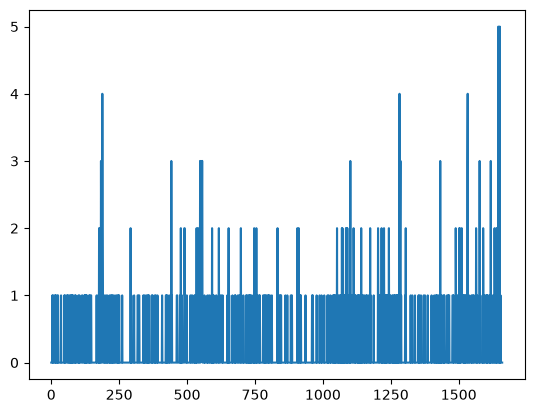

In [ ]:
plt.plot(list(d1['Day_wise Sales'].iloc[1].values.tolist())[0])